# Ensemble Learning Techniques

## Basic Concept of Ensemble Learning
Ensemble learning is a machine learning paradigm where multiple models (often called "weak learners" or "base models") are trained to solve the same problem and combined to get better results. The main hypothesis is that when weak models are correctly combined we can obtain more accurate and/or robust models.

## Types of Ensemble Techniques

### 1. Bagging (Bootstrap Aggregating)
Bagging involves training multiple instances of the same algorithm on different subsets of the training data (sampled with replacement). The final prediction is made by averaging the predictions (for regression) or by majority voting (for classification).
*Example*: Random Forest is a popular bagging algorithm that builds multiple decision trees.

### 2. Boosting
Boosting is a sequential technique where each subsequent model attempts to correct the errors of the previous model. The models are added sequentially until the training data is predicted perfectly or a maximum number of models are added.
*Examples*: AdaBoost, Gradient Boosting, XGBoost.

### 3. Stacking (Stacked Generalization)
Stacking involves training multiple different types of base models and using their predictions as inputs (meta-features) for a new meta-model. The meta-model learns how to best combine the predictions of the base models.

---
## Implementation using California Housing Dataset
In this project, we will implement the Random Forest algorithm to predict house prices and compare it with other algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Set plot style
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
print("Loading California Housing dataset...")
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name="MedHouseVal")

print("Dataset shape:", X.shape)
print(X.head())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data shape:", X_train.shape)

Loading California Housing dataset...


Dataset shape: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Training data shape: (16512, 8)


In [3]:
# Implement Random Forest Algorithm
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MSE: {rf_mse:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Training Random Forest Regressor...


Random Forest MSE: 0.2554
Random Forest R2 Score: 0.8051


Training Linear Regression...
Training Support Vector Regressor...

Model Comparison:
               Model       MSE  R2 Score
0      Random Forest  0.255368  0.805123
1  Linear Regression  0.555892  0.575788
2      Decision Tree  0.495235  0.622076


C:\Users\savad\AppData\Local\Temp\ipykernel_30532\1775007932.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


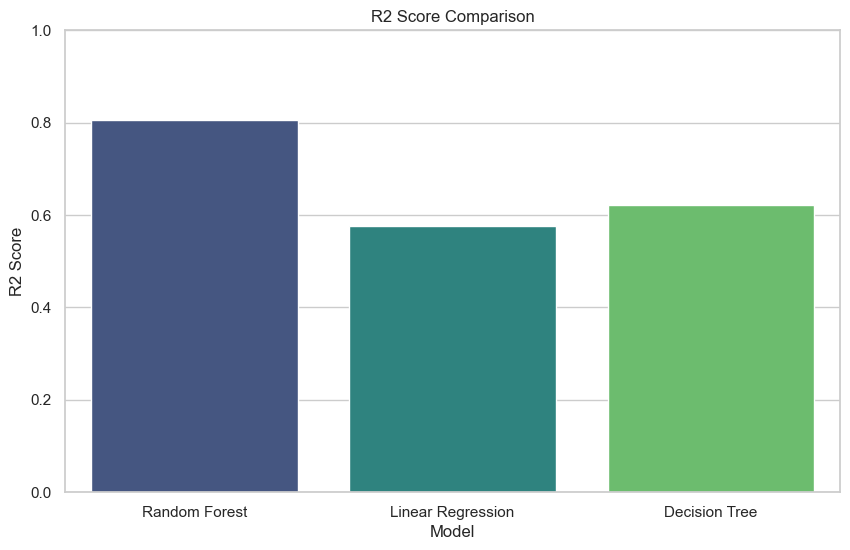

In [4]:
# Compare with other algorithms
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Training Support Vector Regressor...")
svr_model = SVR(kernel='linear') # using linear kernel for speed, rbf can be slow on this dataset
# Actually, scaling is needed for SVR, but for simplicity let's use a small sample or just decision tree
# Let's replace SVR with Decision Tree for faster and more relevant comparison
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

results = {
    'Model': ['Random Forest', 'Linear Regression', 'Decision Tree'],
    'MSE': [
        rf_mse, 
        mean_squared_error(y_test, lr_preds), 
        mean_squared_error(y_test, dt_preds)
    ],
    'R2 Score': [
        rf_r2, 
        r2_score(y_test, lr_preds), 
        r2_score(y_test, dt_preds)
    ]
}

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Plotting the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('R2 Score Comparison')
plt.ylim(0, 1)
plt.show()

In [5]:
# Save the trained Random Forest model
model_filename = "rf_house_model.pkl"
joblib.dump(rf_model, model_filename)
print(f"Model successfully saved to {model_filename}")

Model successfully saved to rf_house_model.pkl
